In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data Cleaning

In [102]:
# description data into a dataframe
df = pd.read_csv('archive/HAM10000_metadata.csv')

In [103]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


The meaning of each and every variable is:

- localization --> refers to the place where the pigmented lesions exists.

- sex --> male/female

- dx_type --> the way the lessions are confirmed (or not): histopathology (histo), examination (follow_up), expert consensus (consensus) <br>
confirmation by in-vivo confocal microscopy (confocal).

- dx --> diagnostic categories --> Actinic keratoses and intraepithelial carcinoma / Bowen's disease (akiec), basal cell carcinoma (bcc) <br>
benign keratosis-like lesions (solar lentigines / seborrheic keratoses and lichen-planus like keratoses, bkl), dermatofibroma (df), melanoma <br>
(mel), melanocytic nevi (nv) and vascular lesions (angiomas, angiokeratomas, pyogenic granulomas and hemorrhage, vasc).

- lesion_id --> The dataset includes lesions which can be tracked by the lesion_id-column within the HAM10000_metadata file.

- image_id --> Each and every image has each unique image_id.

Merge all of the images into one dataframe.

In [104]:
import os
from glob import glob

# combine all of the data from the separate parts 1 and 2 inside the archive folder.
folders = [
    'archive/ham10000_images_part_1',
    'archive/ham10000_images_part_2'
]

imageid_path_dict = {}

for folder in folders:
    for x in glob(os.path.join(folder, '*.jpg')):
        image_id = os.path.splitext(os.path.basename(x))[0]
        imageid_path_dict[image_id] = x

In [105]:
df.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


In [106]:
df.dtypes

lesion_id           str
image_id            str
dx                  str
dx_type             str
age             float64
sex                 str
localization        str
dtype: object

In [107]:
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [108]:
df.duplicated().sum()

np.int64(0)

Since there are only 57 null values i will drop the records with null values.

In [109]:
df = df.dropna()

In [110]:
df.shape

(9958, 7)

On the dx category rename the categories in order to get the fullname of the lessions.

In [111]:
df['dx'].unique()

<StringArray>
['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']
Length: 7, dtype: str

In [ ]:
# Feature Engineering
mapping = {
    'bkl':'bening keratosis-like lesions',
    'akiec':'Actinic Keratoses',
    'nv':'melanocytic nevi',
    'vasc':'Vascular lesions',
    'df':'dermatofibroma',
    'mel':'melanoma',
    'bcc':'Basal cell carcinoma'
}
df['cell_type']=df['dx'].map(mapping)

In [113]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,cell_type
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,bening keratosis-like lesions
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,bening keratosis-like lesions
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,bening keratosis-like lesions
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,bening keratosis-like lesions
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,bening keratosis-like lesions


What is the original size of the pictures ?

In [114]:
from PIL import Image

# in order to see the picture size we 'll get a sample jpg 's 
im = Image.open('archive/ham10000_images_part_1/ISIC_0024312.jpg')
width, height = im.size
print(width,height)

600 450


So the original image has size 600 x 450.

# Combine the original photos with metadata.csv

In [115]:
# Map image_id to full image path
df['path'] = df['image_id'].map(imageid_path_dict)
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,cell_type,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,bening keratosis-like lesions,archive/ham10000_images_part_1/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,bening keratosis-like lesions,archive/ham10000_images_part_1/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,bening keratosis-like lesions,archive/ham10000_images_part_1/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,bening keratosis-like lesions,archive/ham10000_images_part_1/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,bening keratosis-like lesions,archive/ham10000_images_part_2/ISIC_0031633.jpg


In [116]:
df['cell_type'] = df['dx'].map(mapping.get) 
df['cell_type_idx']  = pd.Categorical(df['cell_type']).codes

In [117]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,cell_type,path,cell_type_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,bening keratosis-like lesions,archive/ham10000_images_part_1/ISIC_0027419.jpg,3
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,bening keratosis-like lesions,archive/ham10000_images_part_1/ISIC_0025030.jpg,3
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,bening keratosis-like lesions,archive/ham10000_images_part_1/ISIC_0026769.jpg,3
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,bening keratosis-like lesions,archive/ham10000_images_part_1/ISIC_0025661.jpg,3
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,bening keratosis-like lesions,archive/ham10000_images_part_2/ISIC_0031633.jpg,3


<Axes: xlabel='localization'>

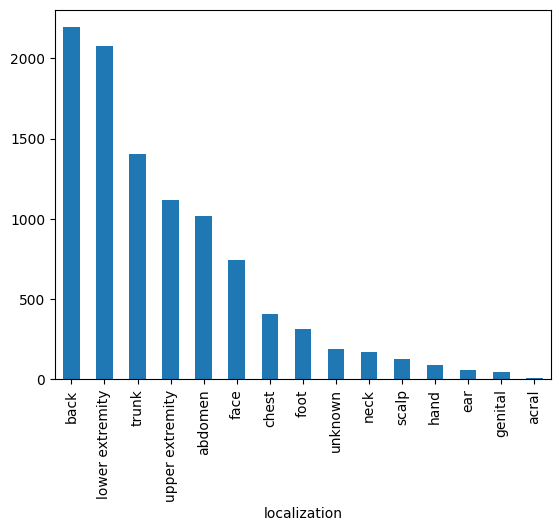

In [118]:
df['localization'].value_counts().plot(kind='bar')

<Axes: xlabel='cell_type'>

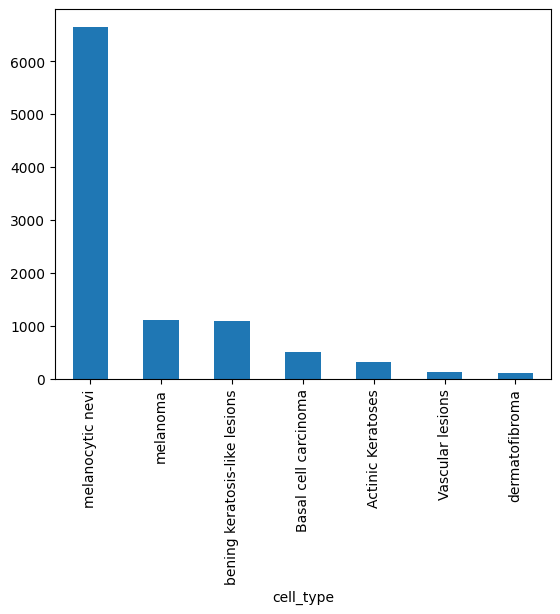

In [327]:
df['cell_type'].value_counts().plot(kind='bar')

As we can see the cell types are highly imbalanced

<Axes: xlabel='sex'>

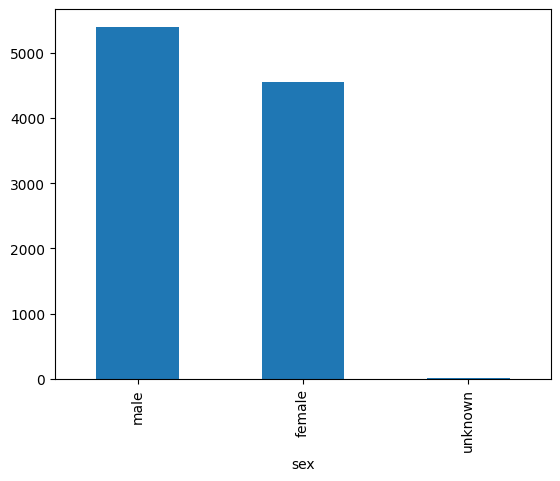

In [119]:
df['sex'].value_counts().plot(kind='bar')

In [120]:
# define the exact number of unknown bars
df['sex'].value_counts()

sex
male       5400
female     4548
unknown      10
Name: count, dtype: int64

since the unknown are only 10 i will drop the whole records with unknown records.

In [121]:
# drop the 10 records. 
df = df.drop(df[df['sex']=='unknown'].index)

# Loading and resizing image
The original shape of image are 450x600 which 

# Loading and resizing of images
To increase our processing performance, we scale every incoming image to the
same resolution of 100 × 75 via the resize(100,75) transform.

In [122]:
df['image'] = df['path'].map(lambda x: np.asarray(Image.open(x).resize((100,75))))

In [123]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,cell_type,path,cell_type_idx,image
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,bening keratosis-like lesions,archive/ham10000_images_part_1/ISIC_0027419.jpg,3,"[[[190, 153, 194], [192, 154, 196], [191, 153,..."
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,bening keratosis-like lesions,archive/ham10000_images_part_1/ISIC_0025030.jpg,3,"[[[23, 13, 22], [24, 14, 24], [25, 14, 28], [3..."
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,bening keratosis-like lesions,archive/ham10000_images_part_1/ISIC_0026769.jpg,3,"[[[185, 127, 137], [189, 133, 147], [194, 136,..."
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,bening keratosis-like lesions,archive/ham10000_images_part_1/ISIC_0025661.jpg,3,"[[[24, 11, 17], [26, 13, 22], [38, 21, 32], [5..."
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,bening keratosis-like lesions,archive/ham10000_images_part_2/ISIC_0031633.jpg,3,"[[[134, 90, 113], [147, 102, 125], [159, 115, ..."


Visualize a sample of each and every kind of cell type.

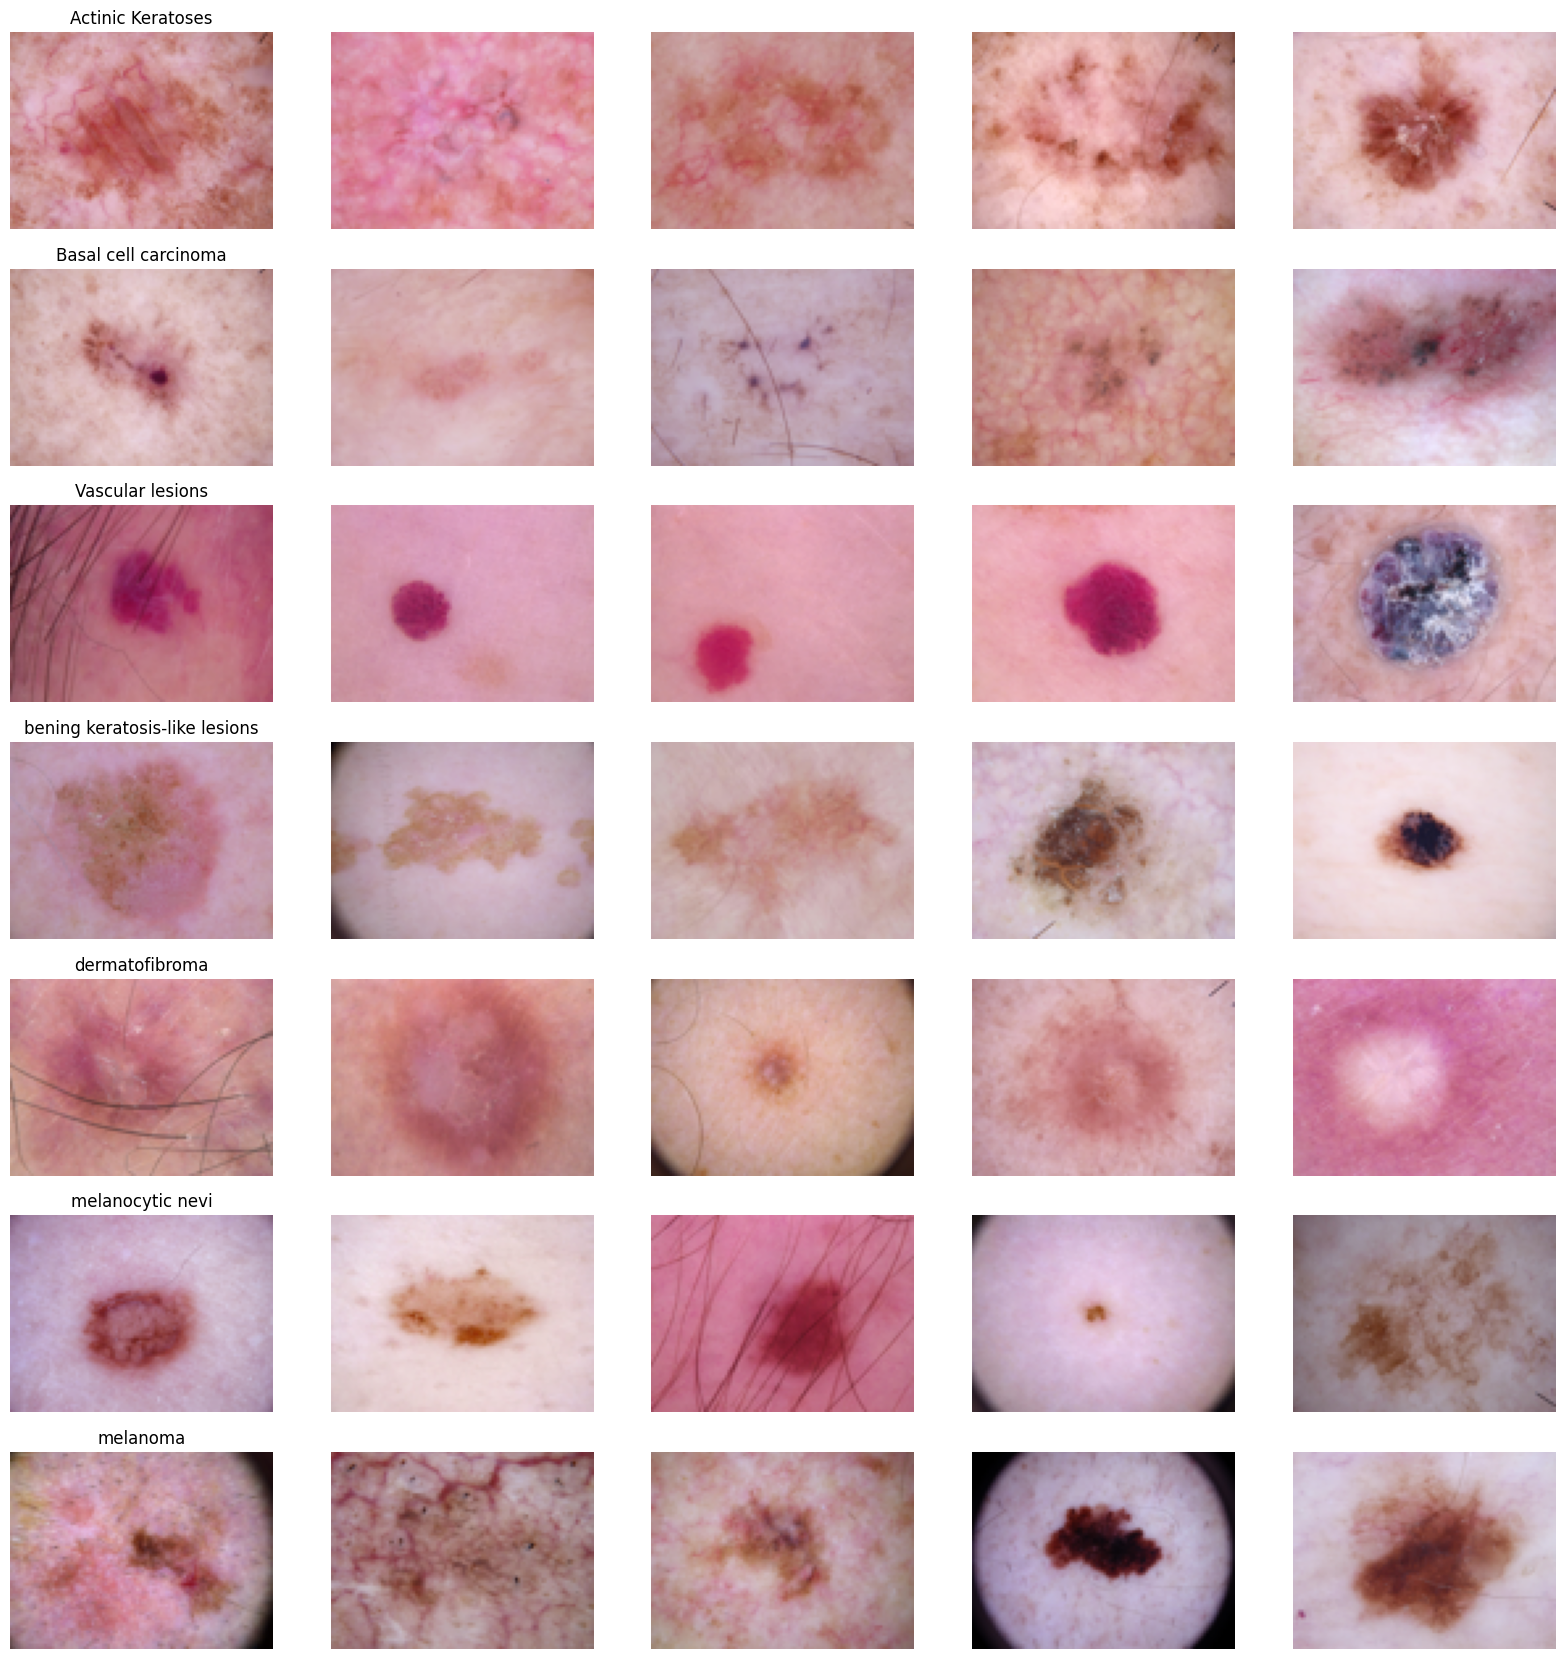

In [166]:
# number of samples to visualize 
n_samples = 5

fig, m_axs = plt.subplots(7, n_samples, figsize = (4*n_samples, 3*7))

for n_axs, (type_name, type_rows) in zip(m_axs,df.sort_values(['cell_type']).groupby('cell_type')):
    n_axs[0].set_title(type_name)
    for c_ax, (_, c_row) in zip(n_axs, type_rows.sample(n_samples, random_state=1234).iterrows()):
        c_ax.imshow(c_row['image'])
        c_ax.axis('off')
fig.savefig('category_samples.png', dpi=300)

# Split the dataset into three parts.
I will split the dataset into train, test and validation parts. <br>

Training: used to learn patterns. <br>

Validation: used to tune and optimize the model. <br>

Testing: used to measure final performance and generalization.

In [270]:
from sklearn.model_selection import train_test_split

X = df.drop("cell_type_idx", axis=1)
y = df["cell_type_idx"]

# split into train and temp.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# split the the temp into validation and test.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [271]:
print(f'The shape of train set is: {X_train.shape}\n')
print(f'The shape of validation set is: {X_val.shape}\n')
print(f'The shape of test set is: {X_test.shape}')

The shape of train set is: (6963, 10)

The shape of validation set is: (1492, 10)

The shape of test set is: (1493, 10)


So the X_train <- is the training subset.<br>

The X_test <- is the test subset. <br>

The X_val <- is the validation subset.

In [272]:
# I will keep on the X values only the images.
X_train = np.asarray(X_train['image'].tolist())

X_test = np.asarray(X_test['image'].tolist())

X_val = np.asarray(X_val['image'].tolist())

Normalize the shape of images.

In [ ]:
X_train_mean  = np.mean(X_train)
X_train_std = np.std(X_train)

X_test_mean = np.mean(X_test)
X_test_std = np.std(X_test)

X_val_mean = np.mean(X_val)
X_val_std = np.std(X_val)

# Apply standardization.
X_train = (X_train - X_train_mean)/X_train_std
x_test = (X_test - X_test_mean)/X_test_std
X_val = (X_val - X_val_mean)/X_val_std

Transform all of them in tensor.

In [274]:
import torch
X_train = torch.tensor(X_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_val   = torch.tensor(y_val.values, dtype=torch.long)
y_test  = torch.tensor(y_test.values, dtype=torch.long)

In [275]:
X_train = X_train.permute(0, 3, 1, 2)
X_val   = X_val.permute(0, 3, 1, 2)
X_test  = X_test.permute(0, 3, 1, 2)

In [276]:
X_train.shape

torch.Size([6963, 3, 75, 100])

So there are 6963 number of samples in the training set. <br>

THe vertical dimension of the image is like 75 pixels. <br>

The horizontal dimension of the image is 100 pixels. <br>

The color channels, are three --> Red, Green, Blue.

In [277]:
y_train.shape

torch.Size([6963])

In [278]:
from torch.utils.data import TensorDataset

# Create a dataset for each and every spliited dataset
train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)
test_dataset  = TensorDataset(X_test, y_test)

In [279]:
train_dataset

In [280]:
from torch.utils.data import DataLoader

batch_size=64
train_data_loader = DataLoader(train_dataset, batch_size=batch_size)
val_data_loader = DataLoader(val_dataset, batch_size=batch_size)
test_data_loader = DataLoader(test_dataset, batch_size=batch_size)

# ANN

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleNet(nn.Module):
    
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(75*100*3, 84)
        self.fc2 = nn.Linear(84, 50)
        self.fc3 = nn.Linear(50,7)
    def forward(self,x):
        x = x.view(x.size(0), -1) # conver the image into 1D tensor
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)             # raw logits, no softmax because i use CrossEntropyLoss which incorporate softmax
        return x
    
simplenet = SimpleNet()

In [308]:
import torch
# my laptop will use cpu since it cannot use cuda.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [309]:
import torch.optim as optim

optimizer = optim.Adam(simplenet.parameters(), lr=0.001)

In [325]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def train(model, optimizer, loss_fn, train_loader, val_loader,
          epochs=20, device="cpu"):
    
    losses = []
    
    for epoch in range(epochs):
        
        training_loss = 0.0
        valid_loss = 0.0
        model.train()
        
        for inputs, targets in train_loader:
            
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            
            loss.backward()
            optimizer.step()
            
            training_loss += loss.item()
        
        training_loss /= len(train_loader)
        
        model.eval()
        num_correct = 0
        num_examples = 0    
        for batch in val_loader:
            
            inputs, targets = batch
            inputs = inputs.to(device)
            output = model(inputs)
            targets = targets.to(device)
            loss = loss_fn(output,targets)
            valid_loss += loss.data.item()
            correct = torch.eq(torch.max(F.softmax(output), dim=1)[1],
            targets).view(-1)
            num_correct += torch.sum(correct).item()
            num_examples += correct.shape[0]

        losses.append(loss.item())    
        valid_loss /= len(val_loader)
        
        # Calculate the accuracy
        accuracy = num_correct/num_examples                    
        print(
            f"Epoch: {epoch+1}, "
            f"Training Loss: {training_loss:.4f}, "
            f"Validation Loss: {valid_loss:.4f}, "
            f"Accuracy: {accuracy:.4f}"
        )
        # Plot the loss curve
        
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.show()
    

In [ ]:
train(simplenet, optimizer, torch.nn.CrossEntropyLoss(weight=class_weights),
train_data_loader, test_data_loader)

RuntimeError: weight tensor should be defined either for all 7 classes or no classes but got weight tensor of shape: [2]